In [2]:
import pandas as pd 
import numpy as np

In [7]:
df= pd.read_csv("EastWestAirlines.csv")
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [8]:
df.shape

(3999, 12)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [10]:
df.describe()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1160.764358,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,1.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


In [11]:
df.isnull().sum()

ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [15]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

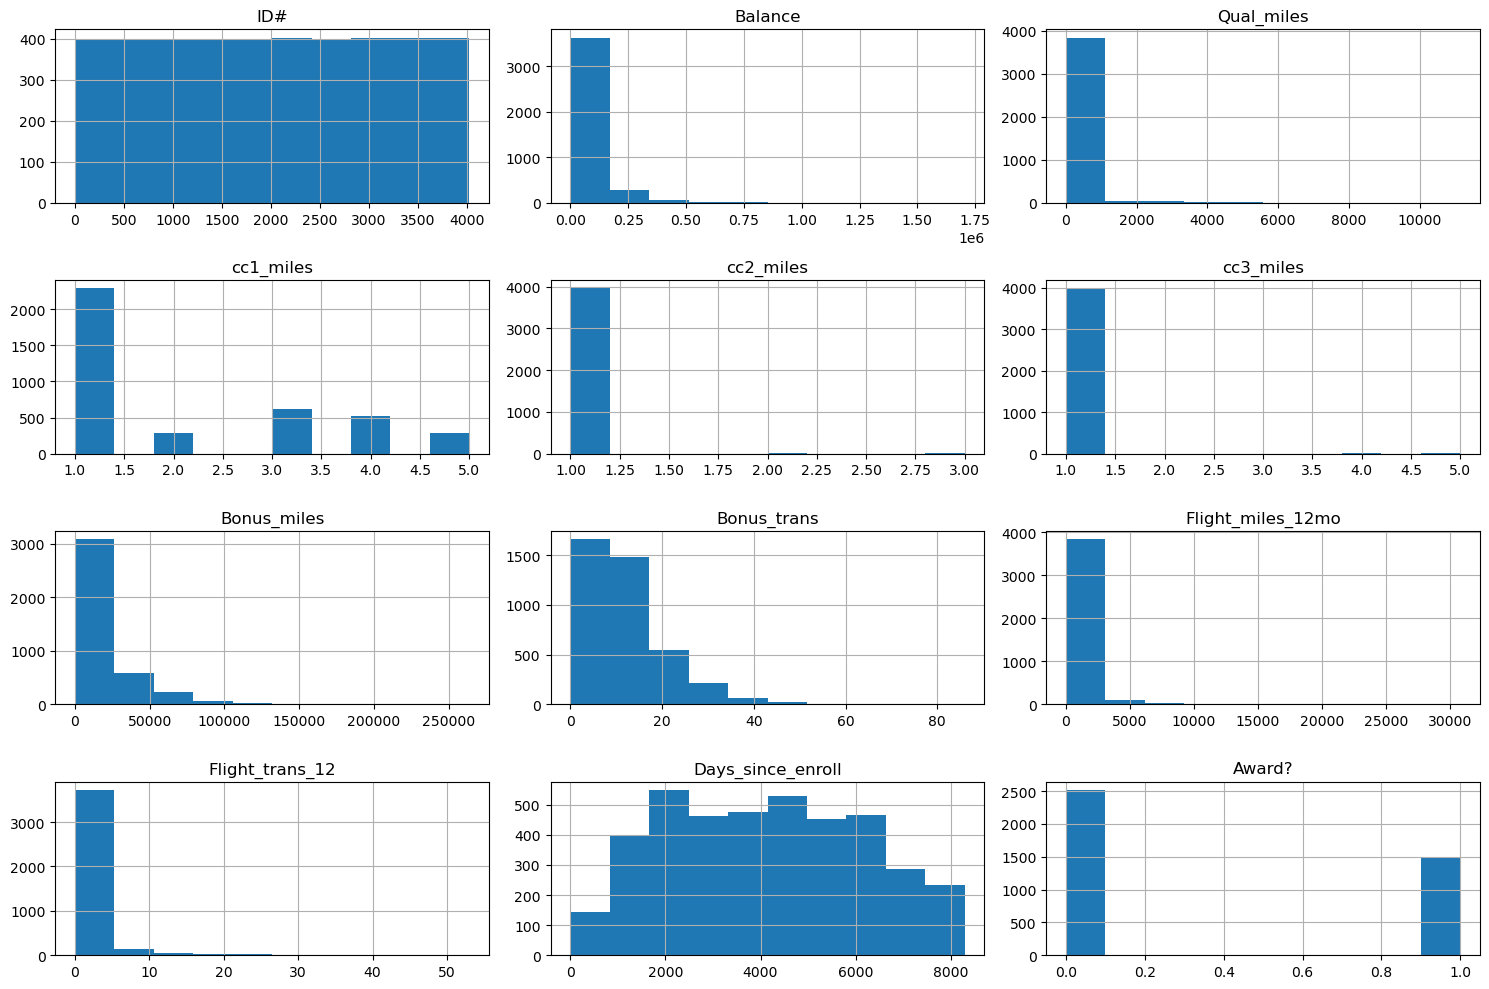

In [16]:
#Histograms
import matplotlib.pyplot as plt

df.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

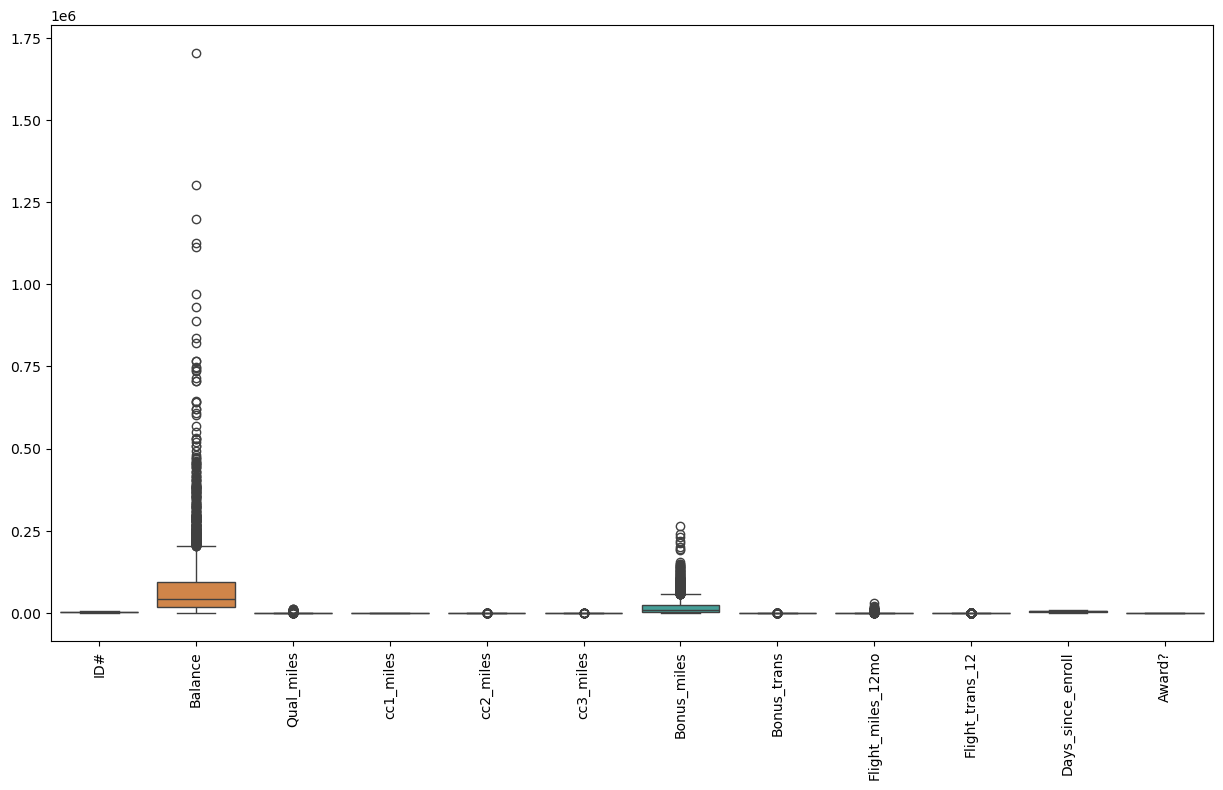

In [17]:
#Boxplots
import seaborn as sns

plt.figure(figsize=(15,8))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

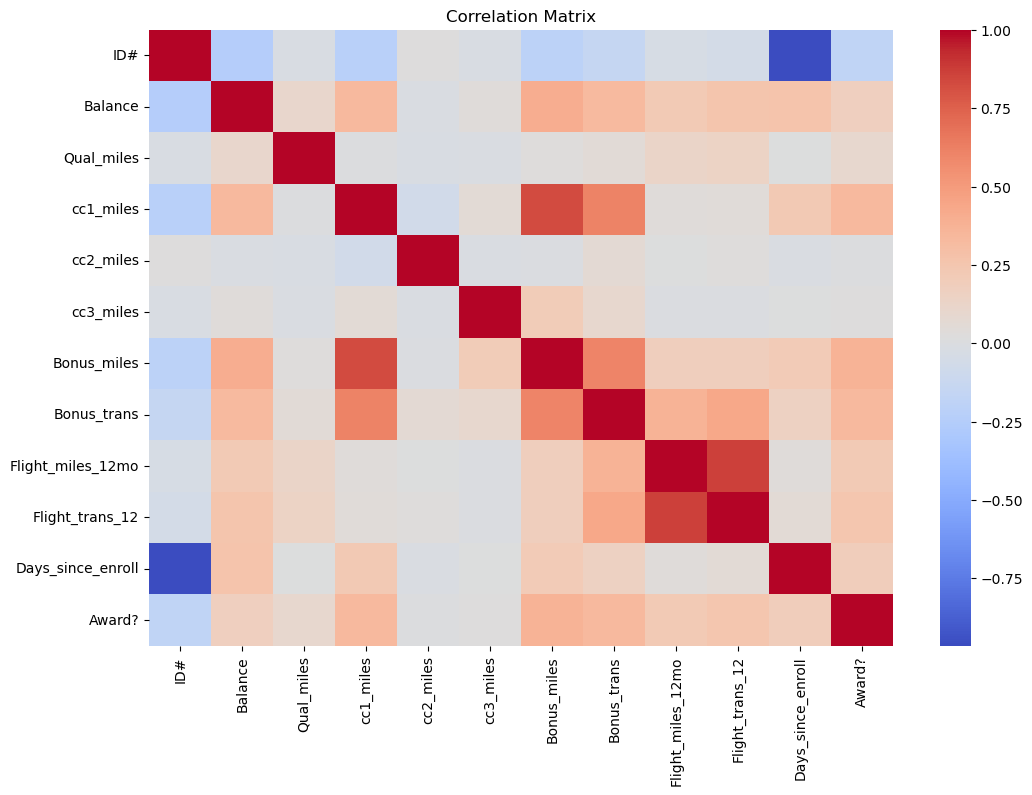

In [18]:
#Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [19]:
#K-Means Clustering
    # Elbow Method
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )
    
    kmeans.fit(X_scaled)
    
    wcss.append(kmeans.inertia_)

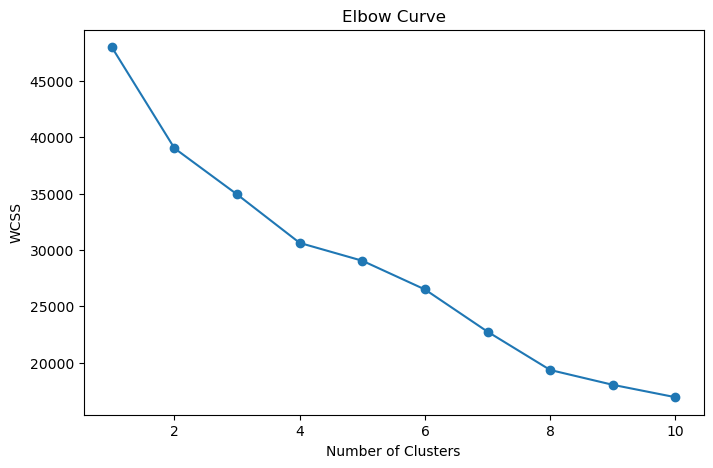

In [20]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11),wcss,marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Curve")
plt.show()

In [21]:
#Apply K-Means
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

kmeans_labels = kmeans.fit_predict(X_scaled)

In [23]:
#PCA for Visualization
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

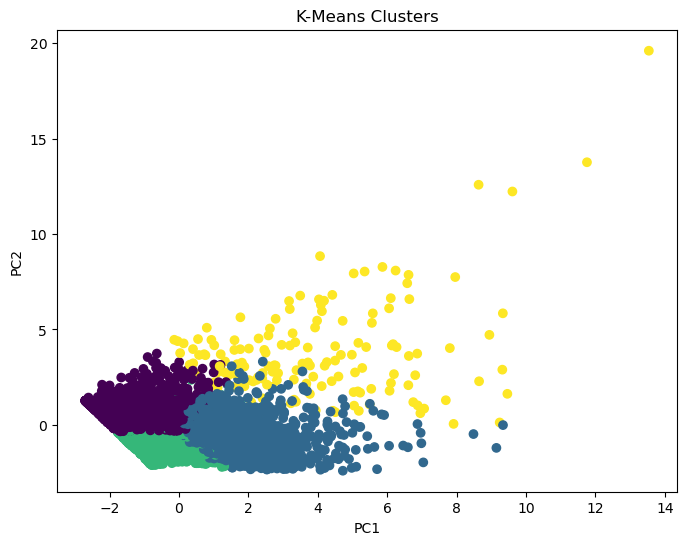

In [24]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=kmeans_labels,
    cmap='viridis'
)

plt.title("K-Means Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

In [25]:
#DBSCAN Clustering
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

db_labels = dbscan.fit_predict(X_scaled)

In [26]:
#Check Clusters
np.unique(db_labels)

array([-1,  0,  1,  2,  3,  4])

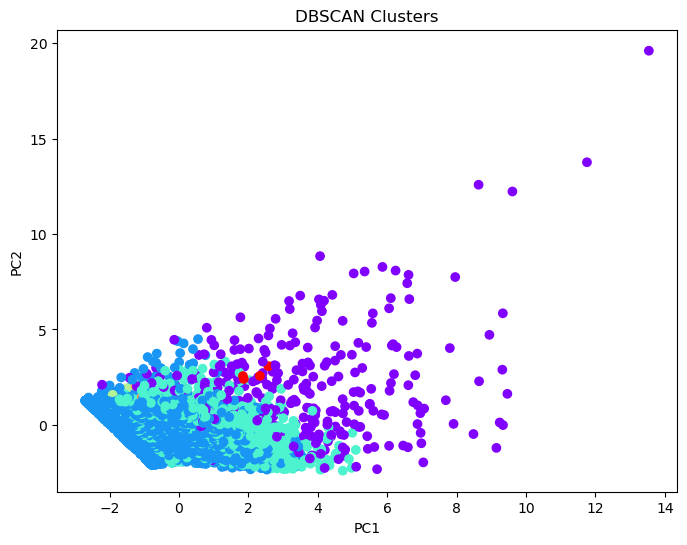

In [27]:
#Visualize DBSCAN Clusters
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=db_labels,
    cmap='rainbow'
)

plt.title("DBSCAN Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

In [28]:
#Silhouette Score for K-Means
from sklearn.metrics import silhouette_score

kmeans_score = silhouette_score(
    X_scaled,
    kmeans_labels
)

print(
    "K-Means Silhouette Score:",
    kmeans_score
)

K-Means Silhouette Score: 0.22808887010836637


In [29]:
#Silhouette Score for DBSCAN
dbscan_score = silhouette_score(
    X_scaled,
    db_labels
)

print(
    "DBSCAN Silhouette Score:",
    dbscan_score
)


DBSCAN Silhouette Score: 0.1895328629344176


In [ ]:
Conclusion:

K-Means and DBSCAN clustering algorithms were successfully implemented on the EastWest Airlines dataset.

K-Means efficiently grouped customers into distinct clusters, while DBSCAN identified dense regions and detected outliers.

Feature scaling improved clustering performance, and PCA enabled effective visualization of clusters in two dimensions.

Based on silhouette score, the clustering quality was evaluated and compared. K-Means performed better for well-separated clusters, whereas DBSCAN was effective in handling noise and irregular cluster shapes.